In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                              classification_report, confusion_matrix)
from datasets import load_dataset
import re
import time

# GPU kontrol
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Reproducibility için seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Kullanılan cihaz: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [4]:
# IMDB veri setini yükle
print("IMDB veri seti yükleniyor...")
dataset = load_dataset("imdb")

train_texts = dataset['train']['text']
train_labels = dataset['train']['label']
test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

print(f"Train: {len(train_texts)} örnek")
print(f"Test:  {len(test_texts)} örnek")
print(f"Örnek yorum: {train_texts[0][:100]}...")
print(f"Etiketi: {'Pozitif' if train_labels[0] == 1 else 'Negatif'}")

IMDB veri seti yükleniyor...
Train: 25000 örnek
Test:  25000 örnek
Örnek yorum: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
Etiketi: Negatif


In [5]:
# Metin temizleme
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)      # HTML etiketleri
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Özel karakterler
    text = text.lower().strip()
    return text

# Vocabulary oluştur
print("Metinler temizleniyor...")
train_clean = [clean_text(t) for t in train_texts]
test_clean  = [clean_text(t) for t in test_texts]

# Kelime frekansı
all_words = []
for text in train_clean:
    all_words.extend(text.split())

word_freq = Counter(all_words)
print(f"Toplam benzersiz kelime: {len(word_freq)}")

# Vocabulary — en sık 20000 kelime
VOCAB_SIZE = 20000
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in word_freq.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

print(f"Vocabulary boyutu: {len(vocab)}")
print(f"En sık 10 kelime: {[w for w, _ in word_freq.most_common(10)]}")

Metinler temizleniyor...
Toplam benzersiz kelime: 137900
Vocabulary boyutu: 20000
En sık 10 kelime: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'this', 'i']


In [6]:
MAX_LEN = 256  # Bellek optimizasyonu için 256

def text_to_sequence(text, word2idx, max_len):
    tokens = text.split()[:max_len]
    seq = [word2idx.get(w, 1) for w in tokens]  # 1 = <UNK>
    # Padding
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))  # 0 = <PAD>
    return seq

print("Sequenceler oluşturuluyor...")
train_seqs = [text_to_sequence(t, word2idx, MAX_LEN) for t in train_clean]
test_seqs  = [text_to_sequence(t, word2idx, MAX_LEN) for t in test_clean]

# PyTorch Dataset
class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels, dtype=torch.float)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# DataLoader
BATCH_SIZE = 64

train_dataset = IMDBDataset(train_seqs, train_labels)
test_dataset  = IMDBDataset(test_seqs,  test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batch sayısı: {len(train_loader)}")
print(f"Test batch sayısı:  {len(test_loader)}")
print(f"MAX_LEN: {MAX_LEN}, BATCH_SIZE: {BATCH_SIZE}")

Sequenceler oluşturuluyor...
Train batch sayısı: 391
Test batch sayısı:  391
MAX_LEN: 256, BATCH_SIZE: 64


In [7]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super(BiLSTMClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, 
            hidden_dim, 
            num_layers=n_layers,
            bidirectional=True, 
            batch_first=True, 
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 çünkü bidirectional
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        # Son iki hidden state'i birleştir (ileri + geri)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden).squeeze(1)

# Model parametreleri
EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.3

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(device)

# Parametre sayısı
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parametreleri: {total_params:,}")
print(model)

Model parametreleri: 4,928,001
BiLSTMClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


In [8]:
# Loss ve optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)
        
        optimizer.zero_grad()
        predictions = model(sequences)
        loss = criterion(predictions, labels)
        loss.backward()
        
        # Gradient clipping — exploding gradient önlemi
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(predictions) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    
    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            
            predictions = model(sequences)
            loss = criterion(predictions, labels)
            
            probs = torch.sigmoid(predictions)
            preds = (probs >= 0.5).long()
            
            total_loss += loss.item()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc  = correct / total
    f1   = f1_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)
    loss = total_loss / len(loader)
    
    return loss, acc, f1, auc, all_preds, all_probs, all_labels

print("Eğitim fonksiyonları hazır.")
print(f"Optimizer: Adam, lr=0.001")
print(f"Loss: BCEWithLogitsLoss")
print(f"Gradient clipping: max_norm=1.0")

Eğitim fonksiyonları hazır.
Optimizer: Adam, lr=0.001
Loss: BCEWithLogitsLoss
Gradient clipping: max_norm=1.0


In [9]:
N_EPOCHS = 5
best_val_auc = 0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Eğitim başlıyor...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Val AUC':<10} {'Süre'}")
print("-" * 75)

start_total = time.time()

for epoch in range(N_EPOCHS):
    start = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1, val_auc, _, _, _ = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    elapsed = time.time() - start
    
    # En iyi modeli kaydet
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_bilstm.pt')
        marker = " ← En iyi"
    else:
        marker = ""
    
    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f} {val_auc:<10.4f} {elapsed:.0f}s{marker}")

total_time = time.time() - start_total
print(f"\nToplam eğitim süresi: {total_time/60:.1f} dakika")
print(f"En iyi Val AUC: {best_val_auc:.4f}")

Eğitim başlıyor...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Val AUC    Süre
---------------------------------------------------------------------------
1        0.6694       0.5784       0.6849       0.5139       0.5757     179s ← En iyi
2        0.6143       0.6586       0.6542       0.7205       0.8157     177s ← En iyi
3        0.5292       0.7521       0.4468       0.8089       0.8766     174s ← En iyi
4        0.4166       0.8191       0.4728       0.8089       0.8820     177s ← En iyi
5        0.3577       0.8494       0.3608       0.8441       0.9198     174s ← En iyi

Toplam eğitim süresi: 14.7 dakika
En iyi Val AUC: 0.9198


In [10]:
# En iyi modeli yükle
model.load_state_dict(torch.load('best_bilstm.pt'))
print("En iyi model yüklendi.")

# Final değerlendirme
_, test_acc, test_f1, test_auc, test_preds, test_probs, test_labels_list = evaluate(
    model, test_loader, criterion, device
)

print("\n" + "="*50)
print("BiLSTM — FINAL TEST SONUÇLARI")
print("="*50)
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")
print("\nDetaylı Rapor:")
print(classification_report(test_labels_list, test_preds, 
                            target_names=['Negatif', 'Pozitif']))

En iyi model yüklendi.

BiLSTM — FINAL TEST SONUÇLARI
Accuracy : 0.8441 (84.41%)
F1 Score : 0.8433
ROC-AUC  : 0.9198

Detaylı Rapor:
              precision    recall  f1-score   support

     Negatif       0.84      0.85      0.84     12500
     Pozitif       0.85      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



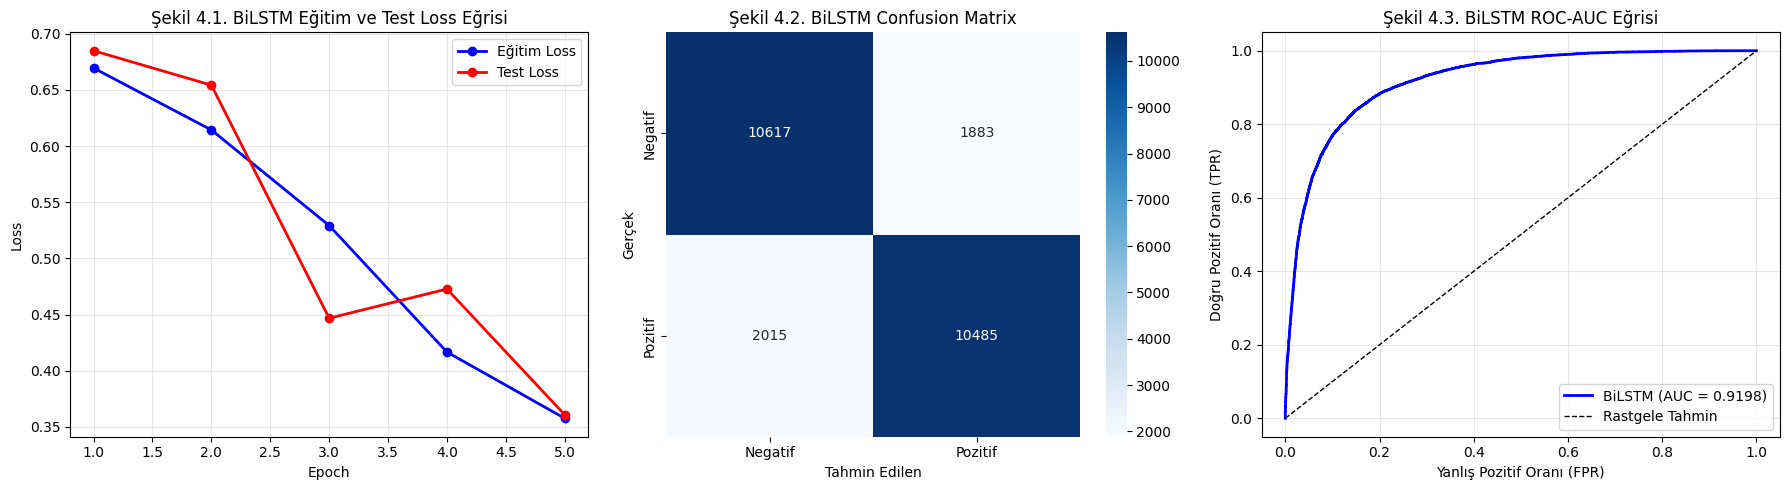

Grafikler kaydedildi: figures/bilstm_results.png


In [11]:
import os
os.makedirs('figures', exist_ok=True)

from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Şekil 1: Eğitim/Doğrulama Loss ---
axes[0].plot(range(1, N_EPOCHS+1), train_losses, 'b-o', label='Eğitim Loss', linewidth=2)
axes[0].plot(range(1, N_EPOCHS+1), val_losses,   'r-o', label='Test Loss',   linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Şekil 4.1. BiLSTM Eğitim ve Test Loss Eğrisi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Şekil 2: Confusion Matrix ---
cm = confusion_matrix(test_labels_list, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'])
axes[1].set_xlabel('Tahmin Edilen')
axes[1].set_ylabel('Gerçek')
axes[1].set_title('Şekil 4.2. BiLSTM Confusion Matrix')

# --- Şekil 3: ROC-AUC Eğrisi ---
fpr, tpr, _ = roc_curve(test_labels_list, test_probs)
axes[2].plot(fpr, tpr, 'b-', linewidth=2, label=f'BiLSTM (AUC = {test_auc:.4f})')
axes[2].plot([0,1], [0,1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[2].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[2].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[2].set_title('Şekil 4.3. BiLSTM ROC-AUC Eğrisi')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/bilstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafikler kaydedildi: figures/bilstm_results.png")

In [12]:
# Yanlış sınıflandırılan örnekleri bul
test_texts_list = list(test_texts)
errors = []

for i, (true, pred, prob) in enumerate(zip(test_labels_list, test_preds, test_probs)):
    if true != pred:
        errors.append({
            'text': test_texts_list[i][:300],
            'true': 'Pozitif' if true == 1 else 'Negatif',
            'pred': 'Pozitif' if pred == 1 else 'Negatif',
            'prob': prob
        })

print(f"Toplam hata: {len(errors)} / {len(test_labels_list)}")
print(f"Hata oranı: {len(errors)/len(test_labels_list)*100:.2f}%")
print("\n" + "="*60)
print("YANLIŞ SINIFLANDIRILAN ÖRNEKLER (İlk 5)")
print("="*60)

for i, err in enumerate(errors[:5]):
    print(f"\n--- Örnek {i+1} ---")
    print(f"Gerçek  : {err['true']}")
    print(f"Tahmin  : {err['pred']}")
    print(f"Olasılık: {err['prob']:.4f}")
    print(f"Metin   : {err['text']}...")
    print()

Toplam hata: 3898 / 25000
Hata oranı: 15.59%

YANLIŞ SINIFLANDIRILAN ÖRNEKLER (İlk 5)

--- Örnek 1 ---
Gerçek  : Negatif
Tahmin  : Pozitif
Olasılık: 0.9607
Metin   : First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti...


--- Örnek 2 ---
Gerçek  : Negatif
Tahmin  : Pozitif
Olasılık: 0.7131
Metin   : Isaac Florentine has made some of the best western Martial Arts action movies ever produced. In particular US Seals 2, Cold Harvest, Special Forces and Undisputed 2 are all action classics. You can tell Isaac has a real passion for the genre and his films are always eventful, creative and sharp affa...


--- Örnek 3 ---
Gerçek  : Negatif
Tahmin  : Pozitif
Olasılık: 0.7326
Metin   : Blind Date (Columbia Pictures, 1934), was a decent film, but I h

Yorum Uzunluğuna Göre BiLSTM Performansı:
Grup                 Örnek Sayısı    Doğruluk (%)
--------------------------------------------------
Kısa (0-50)          657             88.28%
Orta (51-200)        14265           86.11%
Uzun (201+)          10078           81.74%


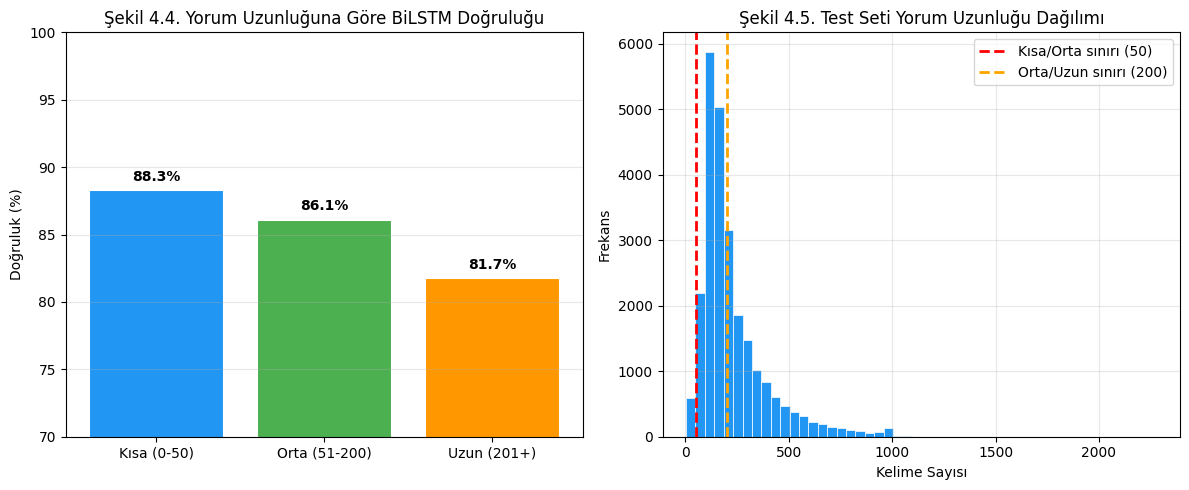

Grafik kaydedildi: figures/length_analysis.png


In [13]:
# Yorum uzunluklarını hesapla
test_lengths = [len(t.split()) for t in test_texts]

# Uzunluk grupları
groups = {'Kısa (0-50)': [], 'Orta (51-200)': [], 'Uzun (201+)': []}
group_correct = {'Kısa (0-50)': 0, 'Orta (51-200)': 0, 'Uzun (201+)': 0}

for length, true, pred in zip(test_lengths, test_labels_list, test_preds):
    if length <= 50:
        g = 'Kısa (0-50)'
    elif length <= 200:
        g = 'Orta (51-200)'
    else:
        g = 'Uzun (201+)'
    groups[g].append(1)
    if true == pred:
        group_correct[g] += 1

# Doğruluk oranları
group_acc = {g: group_correct[g]/len(groups[g])*100 for g in groups}
group_counts = {g: len(groups[g]) for g in groups}

print("Yorum Uzunluğuna Göre BiLSTM Performansı:")
print(f"{'Grup':<20} {'Örnek Sayısı':<15} {'Doğruluk (%)'}")
print("-" * 50)
for g in groups:
    print(f"{g:<20} {group_counts[g]:<15} {group_acc[g]:.2f}%")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart — doğruluk
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = axes[0].bar(group_acc.keys(), group_acc.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Doğruluk (%)')
axes[0].set_title('Şekil 4.4. Yorum Uzunluğuna Göre BiLSTM Doğruluğu')
axes[0].set_ylim(70, 100)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, group_acc.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Histogram — uzunluk dağılımı
axes[1].hist(test_lengths, bins=50, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[1].axvline(50,  color='red',    linestyle='--', linewidth=2, label='Kısa/Orta sınırı (50)')
axes[1].axvline(200, color='orange', linestyle='--', linewidth=2, label='Orta/Uzun sınırı (200)')
axes[1].set_xlabel('Kelime Sayısı')
axes[1].set_ylabel('Frekans')
axes[1].set_title('Şekil 4.5. Test Seti Yorum Uzunluğu Dağılımı')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: figures/length_analysis.png")

In [14]:
# Sonuçları kaydet — karşılaştırma tablosu için
bilstm_results = {
    'model': 'BiLSTM',
    'accuracy': test_acc,
    'f1': test_f1,
    'roc_auc': test_auc,
    'train_time_min': total_time / 60,
    'epochs': N_EPOCHS,
    'params': {
        'vocab_size': VOCAB_SIZE,
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'n_layers': N_LAYERS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'max_len': MAX_LEN,
        'optimizer': 'Adam',
        'lr': 0.001,
        'seed': SEED
    },
    'length_analysis': group_acc
}

import json
with open('bilstm_results.json', 'w', encoding='utf-8') as f:
    json.dump(bilstm_results, f, ensure_ascii=False, indent=2)

print("BiLSTM sonuçları kaydedildi: bilstm_results.json")
print("\n" + "="*50)
print("FAZ 3 — BiLSTM ÖZET")
print("="*50)
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")
print(f"Eğitim   : {total_time/60:.1f} dakika ({N_EPOCHS} epoch)")
print(f"Donanım  : RTX 3050 Ti (4GB VRAM)")
print("="*50)
print("\nFaz 3 tamamlandı! Faz 4 — DistilBERT'e geçmeye hazırız.")

BiLSTM sonuçları kaydedildi: bilstm_results.json

FAZ 3 — BiLSTM ÖZET
Accuracy : 84.41%
F1 Score : 0.8433
ROC-AUC  : 0.9198
Eğitim   : 14.7 dakika (5 epoch)
Donanım  : RTX 3050 Ti (4GB VRAM)

Faz 3 tamamlandı! Faz 4 — DistilBERT'e geçmeye hazırız.
